In [10]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [11]:
DATA_PATH = "notebooks/telco_customer_churn.csv"

df = pd.read_csv(DATA_PATH)

print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [12]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [5]:
print(df["TotalCharges"].isna().sum())

0


In [13]:
X = df.drop(columns=["Churn", "customerID"])

y = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 19)
y shape: (7043,)


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 5634
Testing rows: 1409


In [8]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

X shape: (7043, 19)
y shape: (7043,)
Training rows: 5634
Testing rows: 1409


In [15]:
numeric_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

categorical_features = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [16]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_features
        )
    ]
)

In [17]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [13]:
print("Original training shape:", X_train.shape)
print("Processed training shape:", X_train_processed.shape)

print("Original testing shape:", X_test.shape)
print("Processed testing shape:", X_test_processed.shape)

Original training shape: (5634, 19)
Processed training shape: (5634, 30)
Original testing shape: (1409, 19)
Processed testing shape: (1409, 30)


In [14]:
print(type(X_train_processed))

<class 'numpy.ndarray'>


In [15]:
print("Original training shape:", X_train.shape)
print("Processed training shape:", X_train_processed.shape)
print("Original testing shape:", X_test.shape)
print("Processed testing shape:", X_test_processed.shape)

Original training shape: (5634, 19)
Processed training shape: (5634, 30)
Original testing shape: (1409, 19)
Processed testing shape: (1409, 30)


In [16]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_processed,
    y_train
)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [17]:
y_pred_logistic = logistic_model.predict(
    X_test_processed
)

y_prob_logistic = logistic_model.predict_proba(
    X_test_processed
)[:, 1]

print("Predictions generated.")

Predictions generated.


In [18]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [19]:
accuracy = accuracy_score(
    y_test,
    y_pred_logistic
)

precision = precision_score(
    y_test,
    y_pred_logistic
)

recall = recall_score(
    y_test,
    y_pred_logistic
)

f1 = f1_score(
    y_test,
    y_pred_logistic
)

roc_auc = roc_auc_score(
    y_test,
    y_prob_logistic
)

In [20]:
print("Logistic Regression Performance")
print("--------------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Logistic Regression Performance
--------------------------------
Accuracy : 0.8070
Precision: 0.6604
Recall   : 0.5615
F1 Score : 0.6069
ROC-AUC  : 0.8422


In [21]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_logistic,
        target_names=["No Churn", "Churn"]
    )
)

              precision    recall  f1-score   support

    No Churn       0.85      0.90      0.87      1035
       Churn       0.66      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [22]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred_logistic
)

print(cm)

[[927 108]
 [164 210]]


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

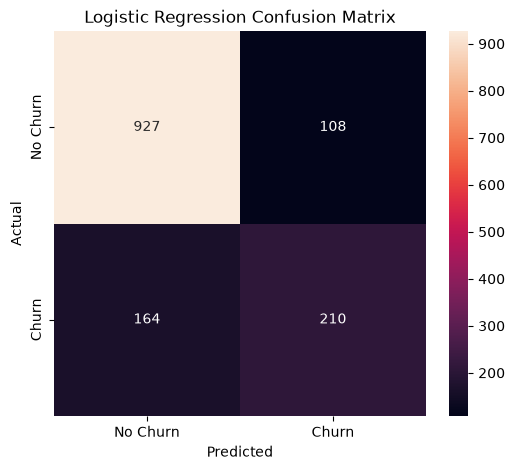

In [26]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [27]:
logistic_results = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1": f1,
    "ROC_AUC": roc_auc
}

logistic_results

{'Model': 'Logistic Regression',
 'Accuracy': 0.8069552874378992,
 'Precision': 0.660377358490566,
 'Recall': 0.5614973262032086,
 'F1': 0.6069364161849711,
 'ROC_AUC': 0.8421710713270816}

In [28]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred_logistic
)

print(cm)

[[927 108]
 [164 210]]


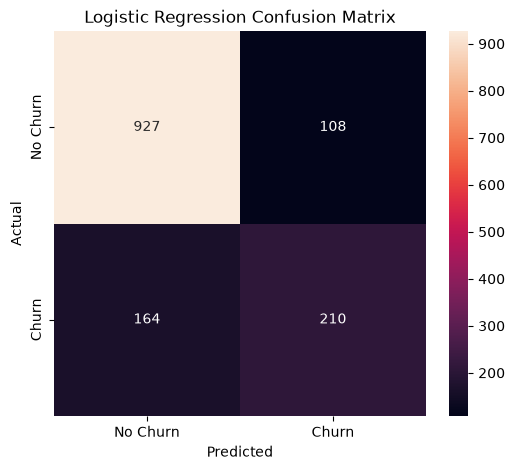

In [29]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [30]:
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)

print("\nConfusion Matrix:")
print(cm)

Accuracy : 0.8069552874378992
Precision: 0.660377358490566
Recall   : 0.5614973262032086
F1 Score : 0.6069364161849711
ROC-AUC  : 0.8421710713270816

Confusion Matrix:
[[927 108]
 [164 210]]


In [20]:
logistic_results = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1": f1,
    "ROC_AUC": roc_auc
}

print(logistic_results)

{'Model': 'Logistic Regression', 'Accuracy': 0.8069552874378992, 'Precision': 0.660377358490566, 'Recall': 0.5614973262032086, 'F1': 0.6069364161849711, 'ROC_AUC': 0.8421710713270816}


In [21]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

random_forest_model.fit(
    X_train_processed,
    y_train
)

print("Random Forest training completed.")

Random Forest training completed.


In [22]:
y_pred_rf = random_forest_model.predict(X_test_processed)

y_prob_rf = random_forest_model.predict_proba(
    X_test_processed
)[:, 1]

print("Random Forest predictions generated.")

Random Forest predictions generated.


In [23]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_roc_auc = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Performance")
print("-------------------------")
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_roc_auc:.4f}")

Random Forest Performance
-------------------------
Accuracy : 0.7757
Precision: 0.5687
Recall   : 0.6417
F1 Score : 0.6030
ROC-AUC  : 0.8270


In [24]:
rf_results = {
    "Model": "Random Forest",
    "Accuracy": rf_accuracy,
    "Precision": rf_precision,
    "Recall": rf_recall,
    "F1": rf_f1,
    "ROC_AUC": rf_roc_auc
}

print(rf_results)

{'Model': 'Random Forest', 'Accuracy': 0.7757274662881476, 'Precision': 0.5687203791469194, 'Recall': 0.6417112299465241, 'F1': 0.6030150753768844, 'ROC_AUC': 0.8269562634012761}


In [36]:
print(logistic_results)
print(rf_results)

{'Model': 'Logistic Regression', 'Accuracy': 0.8069552874378992, 'Precision': 0.660377358490566, 'Recall': 0.5614973262032086, 'F1': 0.6069364161849711, 'ROC_AUC': 0.8421710713270816}
{'Model': 'Random Forest', 'Accuracy': 0.7757274662881476, 'Precision': 0.5687203791469194, 'Recall': 0.6417112299465241, 'F1': 0.6030150753768844, 'ROC_AUC': 0.8269562634012761}


In [18]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(
    X_train_processed,
    y_train
)

print("XGBoost training completed.")

XGBoost training completed.


In [11]:
y_pred_xgb = xgb_model.predict(
    X_test_processed
)

y_prob_xgb = xgb_model.predict_proba(
    X_test_processed
)[:, 1]

print("XGBoost predictions generated.")

XGBoost predictions generated.


In [13]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

xgb_accuracy = accuracy_score(
    y_test,
    y_pred_xgb
)

xgb_precision = precision_score(
    y_test,
    y_pred_xgb
)

xgb_recall = recall_score(
    y_test,
    y_pred_xgb
)

xgb_f1 = f1_score(
    y_test,
    y_pred_xgb
)

xgb_roc_auc = roc_auc_score(
    y_test,
    y_prob_xgb
)

print("XGBoost Performance")
print("-------------------")
print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1 Score : {xgb_f1:.4f}")
print(f"ROC-AUC  : {xgb_roc_auc:.4f}")

XGBoost Performance
-------------------
Accuracy : 0.7991
Precision: 0.6522
Recall   : 0.5214
F1 Score : 0.5795
ROC-AUC  : 0.8440


In [14]:
xgb_results = {
    "Model": "XGBoost",
    "Accuracy": xgb_accuracy,
    "Precision": xgb_precision,
    "Recall": xgb_recall,
    "F1": xgb_f1,
    "ROC_AUC": xgb_roc_auc
}

print(xgb_results)

{'Model': 'XGBoost', 'Accuracy': 0.7991483321504613, 'Precision': 0.6521739130434783, 'Recall': 0.5213903743315508, 'F1': 0.5794947994056464, 'ROC_AUC': 0.8440401457025498}


In [25]:
model_comparison = pd.DataFrame([
    logistic_results,
    rf_results,
    xgb_results
])

model_comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.806955,0.660377,0.561497,0.606936,0.842171
1,Random Forest,0.775727,0.568720,0.641711,0.603015,0.826956
2,XGBoost,0.799148,0.652174,0.521390,0.579495,0.844040


In [26]:
model_comparison.sort_values(
    "ROC_AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
2,XGBoost,0.799148,0.652174,0.521390,0.579495,0.844040
0,Logistic Regression,0.806955,0.660377,0.561497,0.606936,0.842171
1,Random Forest,0.775727,0.568720,0.641711,0.603015,0.826956


In [19]:
import shap

In [20]:
feature_names = preprocessor.get_feature_names_out()

print("Number of processed features:", len(feature_names))




Number of processed features: 30


In [21]:
feature_names[:20]

array(['num__SeniorCitizen', 'num__tenure', 'num__MonthlyCharges',
       'num__TotalCharges', 'cat__gender_Male', 'cat__Partner_Yes',
       'cat__Dependents_Yes', 'cat__PhoneService_Yes',
       'cat__MultipleLines_No phone service', 'cat__MultipleLines_Yes',
       'cat__InternetService_Fiber optic', 'cat__InternetService_No',
       'cat__OnlineSecurity_No internet service',
       'cat__OnlineSecurity_Yes', 'cat__OnlineBackup_No internet service',
       'cat__OnlineBackup_Yes',
       'cat__DeviceProtection_No internet service',
       'cat__DeviceProtection_Yes',
       'cat__TechSupport_No internet service', 'cat__TechSupport_Yes'],
      dtype=object)

In [22]:
processed_test_values = (
    X_test_processed.toarray()
    if hasattr(X_test_processed, "toarray")
    else X_test_processed
)

X_test_processed_df = pd.DataFrame(
    processed_test_values,
    columns=feature_names,
    index=X_test.index
)

X_test_processed_df.head()

,num__SeniorCitizen,num__tenure,num__MonthlyCharges,num__TotalCharges,cat__gender_Male,cat__Partner_Yes,cat__Dependents_Yes,cat__PhoneService_Yes,cat__MultipleLines_No phone service,cat__MultipleLines_Yes,...,cat__StreamingTV_No internet service,cat__StreamingTV_Yes,cat__StreamingMovies_No internet service,cat__StreamingMovies_Yes,cat__Contract_One year,cat__Contract_Two year,cat__PaperlessBilling_Yes,cat__PaymentMethod_Credit card (automatic),cat__PaymentMethod_Electronic check,cat__PaymentMethod_Mailed check
437,-0.441773,1.608483,1.629976,2.706828,1.0,1.0,1.0,1.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0
2280,2.263606,-0.996684,1.168725,-0.610260,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
2235,-0.441773,0.346606,0.445324,0.400116,0.0,1.0,1.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
4460,-0.441773,-0.589626,0.440347,-0.364451,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3761,-0.441773,1.608483,0.588013,1.588421,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0


In [23]:
processed_test_values = (
    X_test_processed.toarray()
    if hasattr(X_test_processed, "toarray")
    else X_test_processed
)

X_test_processed_df = pd.DataFrame(
    processed_test_values,
    columns=feature_names,
    index=X_test.index
)

X_test_processed_df.head()

,num__SeniorCitizen,num__tenure,num__MonthlyCharges,num__TotalCharges,cat__gender_Male,cat__Partner_Yes,cat__Dependents_Yes,cat__PhoneService_Yes,cat__MultipleLines_No phone service,cat__MultipleLines_Yes,...,cat__StreamingTV_No internet service,cat__StreamingTV_Yes,cat__StreamingMovies_No internet service,cat__StreamingMovies_Yes,cat__Contract_One year,cat__Contract_Two year,cat__PaperlessBilling_Yes,cat__PaymentMethod_Credit card (automatic),cat__PaymentMethod_Electronic check,cat__PaymentMethod_Mailed check
437,-0.441773,1.608483,1.629976,2.706828,1.0,1.0,1.0,1.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0
2280,2.263606,-0.996684,1.168725,-0.610260,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
2235,-0.441773,0.346606,0.445324,0.400116,0.0,1.0,1.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
4460,-0.441773,-0.589626,0.440347,-0.364451,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3761,-0.441773,1.608483,0.588013,1.588421,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0


In [24]:
explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(
    X_test_processed_df
)

print("SHAP values calculated.")

SHAP values calculated.


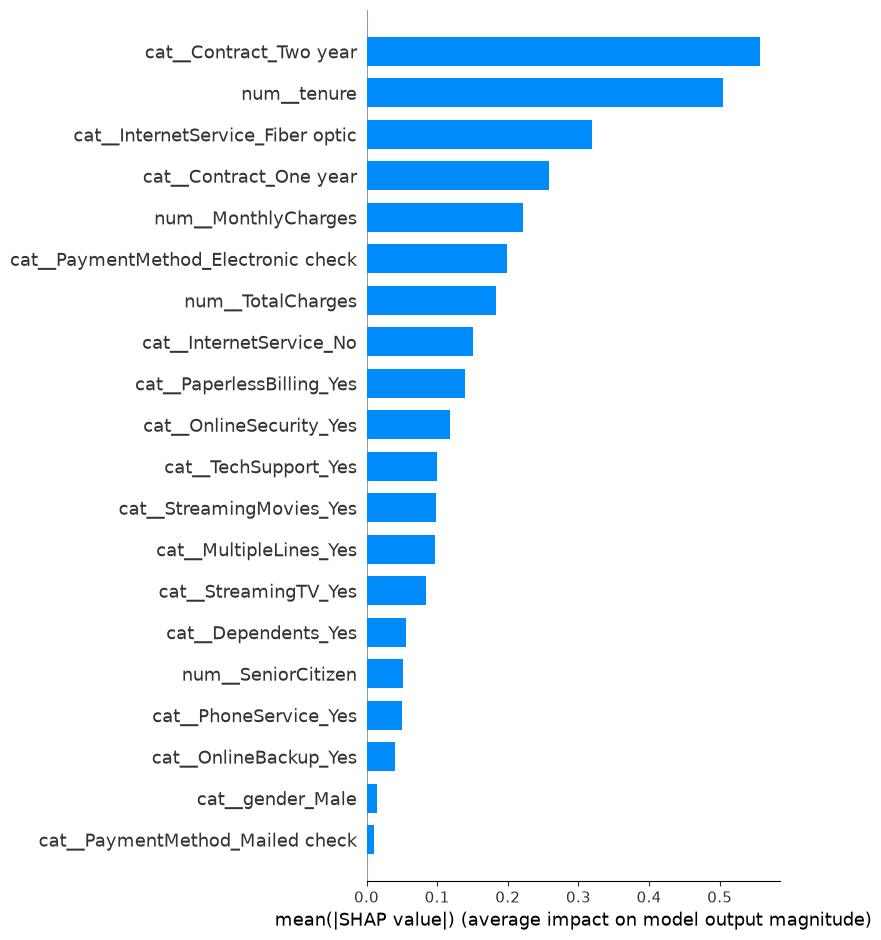

In [25]:
shap.summary_plot(
    shap_values,
    X_test_processed_df,
    plot_type="bar"
)

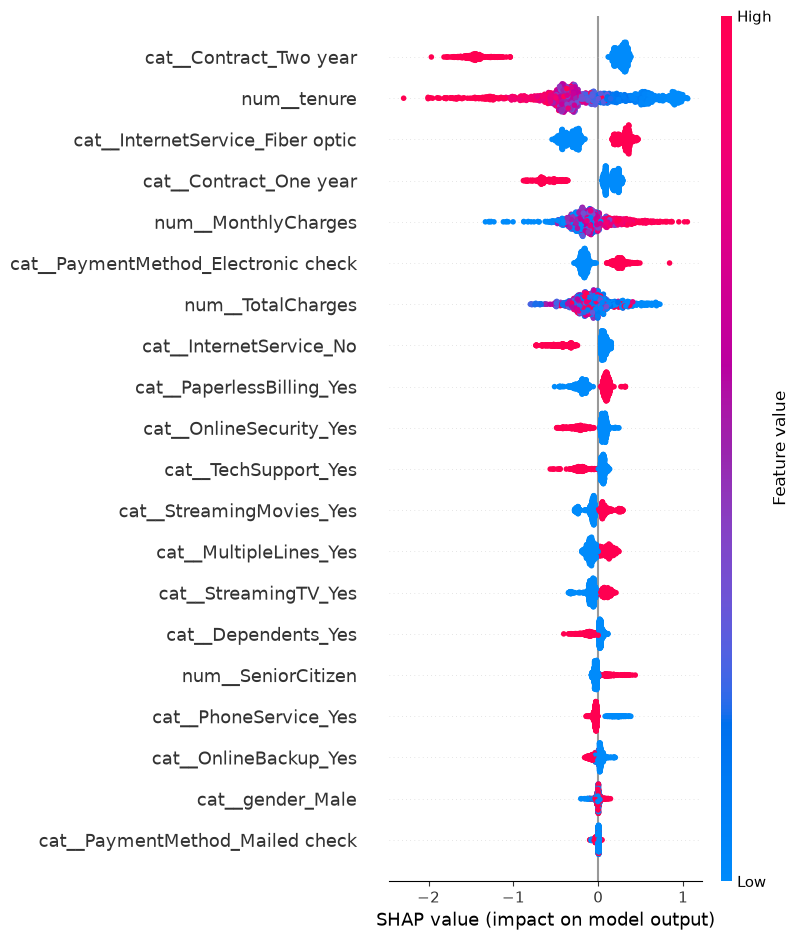

In [26]:
shap.summary_plot(
    shap_values,
    X_test_processed_df
)

## SHAP Explainability Findings

### Main Churn Drivers

The SHAP analysis identifies the following features as the most influential
drivers of the XGBoost churn predictions:

1. [Feature]
2. [Feature]
3. [Feature]
4. [Feature]
5. [Feature]

### Interpretation

[Explain how the most important features influence churn predictions based
on the SHAP summary plot.]

These findings help explain the model's predictions and can later be used
to create customer-risk segments and business recommendations.

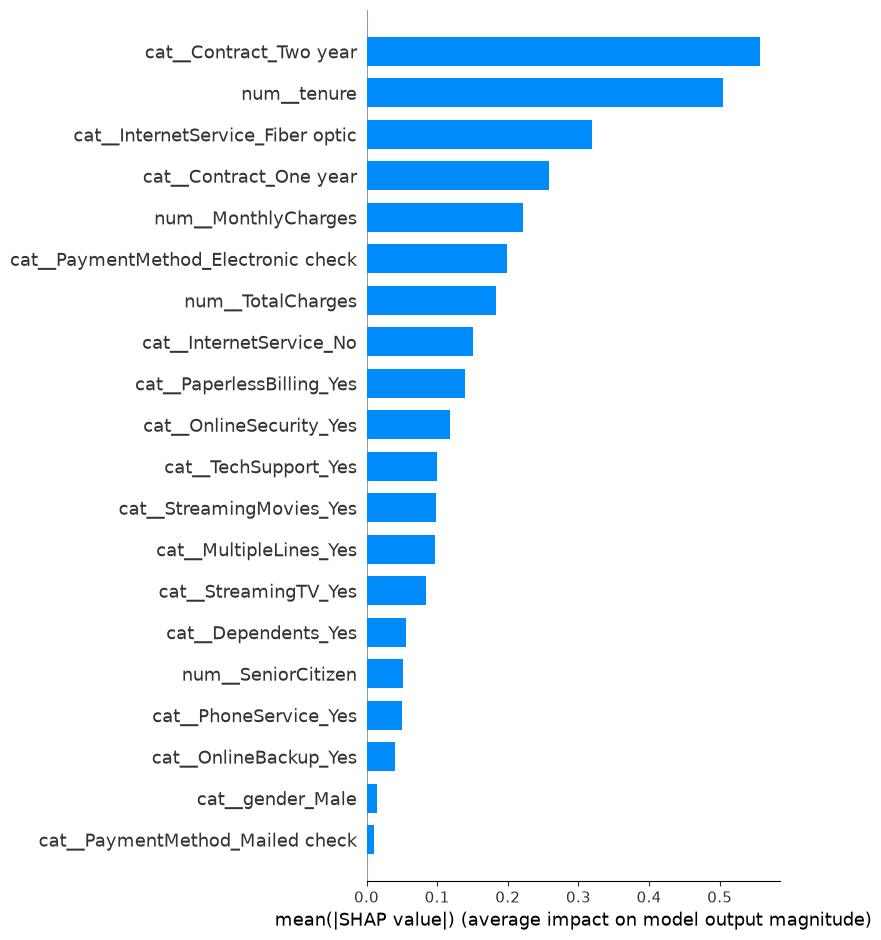

In [27]:
shap.summary_plot(
    shap_values,
    X_test_processed_df,
    plot_type="bar"
)